In [1]:
import pandas as pd
import numpy as np
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

**What is Churn**

*Customer churn refers to customers/clients cancelling their subscription from the service provider (Muhammad Shahid Azeem, 2023).
Service providers utilize churn to understand/predict clients they are likely to lose in a near future, prompting service providers to implement measures to retain existing customers, such retention measure often include:*

- Reduced payment
- Premium packages for less pay
- Free trials/subscriptions, and
- Premium cashback after specific period 

*When done well, this results in*:
- Improved client satisfactions
- Reduced customer turnover**


**Project Objective**

The aim of this study is to use secondary data, namely the Customer Churn Dataset, obtained from kaggle, to build a supervised machine learning algorithm, that allows service providers to predict by classification whether the customer is likely to retain or cancel their subscription.
 Independent variables selected to build the model are: 
- Gender
- Age
- Tenure
- Usage Frequency
- Support calls
- Payment Delay
- Subscription type
- Contract length
- Total spend
- Last Interaction
  
 Dependent (target) variable:
- Whether a customer retained/non-churn (0) or cancelled/churned (1) their subscription


In [2]:
filename ="customer_churn_dataset-training-master.csv"

In [3]:
customer = pd.read_csv(filename)
customer.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


In [4]:
#Check the number of columns in the dataset

customer.shape[1]

12

In [5]:
#Check the number of rows in the dataset

customer.shape[0]

440833

In [6]:
#Print out the Columns names 
customer.columns.to_list()

['CustomerID',
 'Age',
 'Gender',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Contract Length',
 'Total Spend',
 'Last Interaction',
 'Churn']

In [7]:
#Print the columns and datatype 

customer.dtypes

CustomerID           float64
Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [8]:
#Identify duplkicate in the dataset

customer.duplicated().sum()  

#Zero duplicate result found

np.int64(0)

In [9]:
#Identify missing values

null = customer.isnull().sum()
null

#There is one null value across allthe columns

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [10]:
#Remove a missing or null value

customer.dropna(inplace =True)

#Reproint the total number of rows 

customer.shape[0] 
    #The total rows has drropped by 1 from 440833 to 440832 after removing a null value (missing  value)

440832

In [11]:
customer.info()

<class 'pandas.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 38.7 MB


In [12]:
#Convert the CustomerID, Age, Tenure, Support Calls, Patment Delay, Usage Frequency, Last Interaction, Churn from float to interger

customer[['CustomerID','Age','Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay','Last Interaction', 'Churn']] =customer[['CustomerID','Age','Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Last Interaction', 'Churn']].astype(int)

In [13]:
customer

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440829,449996,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440830,449997,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440831,449998,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


In [14]:
#RE-print the final datatype of Customr databases after casting floats into intergers

In [15]:
#Print unique target variable 
for col in ['Churn', 'Gender', 'Subscription Type', 'Contract Length']:
    print(f"\n{col}, {customer[col].unique()}")


Churn, [1 0]

Gender, <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Subscription Type, <StringArray>
['Standard', 'Basic', 'Premium']
Length: 3, dtype: str

Contract Length, <StringArray>
['Annual', 'Monthly', 'Quarterly']
Length: 3, dtype: str


In [16]:
#Remove excess space and upper case the first letter of text objects

for col in ['Gender', 'Subscription Type', 'Contract Length']:
    customer[col] = customer[col].str.strip().str.title()

In [17]:
#Print eandom 10 results

customer.sample(20)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
48995,49733,39,Female,45,19,6,21,Basic,Annual,927.00,21,1
285686,292800,46,Male,43,3,1,11,Basic,Quarterly,622.14,16,0
356017,363132,50,Male,14,27,3,17,Premium,Quarterly,642.81,14,0
325207,332322,46,Male,59,15,4,11,Basic,Annual,773.93,14,0
185637,190448,24,Female,1,20,9,24,Basic,Annual,654.00,21,1
214868,220330,51,Male,29,9,6,17,Premium,Annual,831.18,18,1
6203,6212,26,Male,2,16,8,9,Standard,Monthly,158.00,16,1
108929,112297,26,Male,14,18,8,12,Standard,Annual,555.00,9,1
62813,64184,27,Female,11,9,3,4,Standard,Annual,359.00,3,1
297804,304918,45,Male,59,6,0,20,Standard,Quarterly,775.06,11,0


**Data structure Summary**
- Number of rows: 440833
- Number of columns: 12
- Duplicate counted: 0
- Missing/Null value found: 1
- 1 row removed due to missing values across all variables (Bring total usable data to 440832)


**EXPLORATORY DATA ANALYSIS**

**Outliers**
- Inter Quantile Range (IQR) approach was used to identify outliers
- Zero outliers was detected across all variables

**Analysis**
- Total churned = 249999 and non-churn = 190833
- Equal distribution across subscription types, with standard and premium subscription being slightly favored than basic subscription
- Annual and quarterly contract length spend more compared to monthly
- There is zero non-churn on a monthly contract length
- Most clients are at least 49 years of old, with an average age of ~40 years churned 

**Churn vs Independent variables correlation**
- OneHotEncoding was used to convert categorical values into integers
- StandardScaler was used in numerical variables 
- Correlation is evaluated on Churn against other variables to establish independent  variables influence on a  churn
- Resonable correlation for the following variables
 - Total spend
 - Tenure
 - Usage Frequency
 - Age
 - Payment Delays 
 - Support call 


In [18]:
#Identify outliers in the dataset

numeric_column = customer.select_dtypes(include = 'number').columns

for col in numeric_column:

    #Calculate Q1, Q3, IQR

    Q1 = customer[col].quantile(0.25)

    Q3 = customer[col].quantile(0.75)

    IQR = Q3 - Q1

    #Define the lower and upper limit

    lower_limit = Q1 - 1.5*IQR

    upper_limit = Q3 + 1.5*IQR

    #calculate outliers
    outliers = customer[
        (customer[col] < lower_limit) |
        (customer[col] > upper_limit)
        ]

    #print out the total outliers by the column

    print (F"\n{col:}, {len(outliers)}, outliers")

    #There are no outliers in the dataset


CustomerID, 0, outliers

Age, 0, outliers

Tenure, 0, outliers

Usage Frequency, 0, outliers

Support Calls, 0, outliers

Payment Delay, 0, outliers

Total Spend, 0, outliers

Last Interaction, 0, outliers

Churn, 0, outliers


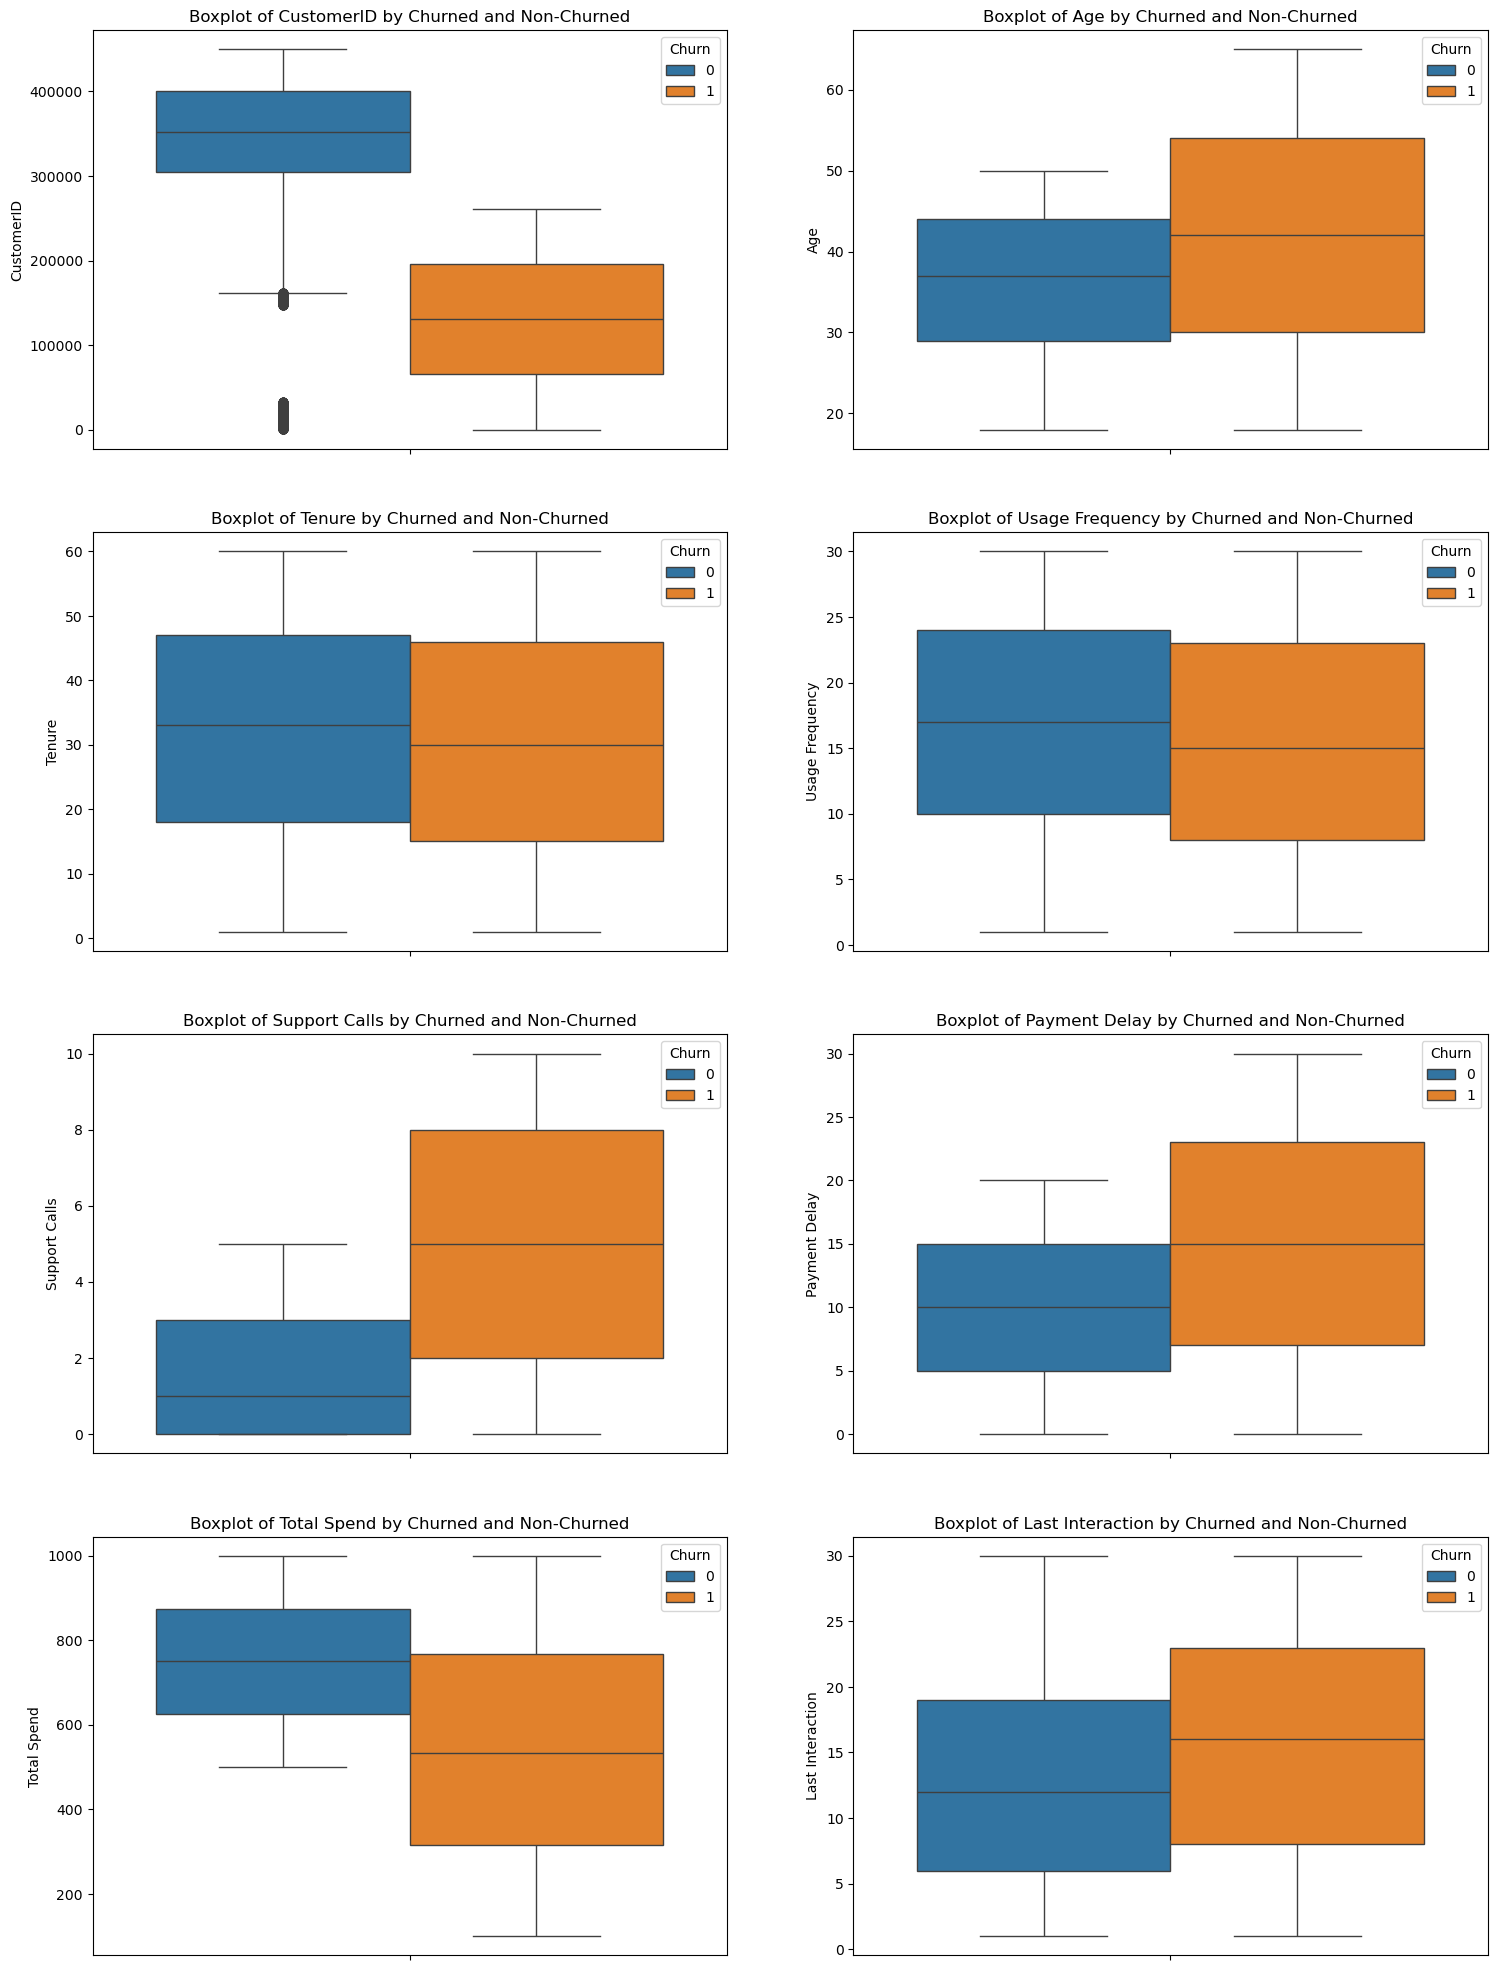

In [19]:
#Use a whisker and plot diagrams to understand the distribution of the numeric variables

numerical_variables  = customer.select_dtypes(include = ['float64', 'int32']).columns.drop('Churn')
fig, axes = plt.subplots(4,2, figsize = (18,25))

for ax, col in zip(axes.flat, numerical_variables):
    
    sns.boxplot(y = customer[col], hue = customer["Churn"], ax=ax)

    ax.set_title (f"Boxplot of {col} by Churned and Non-Churned")
    ax.set_label(F"{col}")
plt.show()

In [20]:
#Understand data description

customer.describe(include ='all').round(4)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.0000,440832.0000,440832,440832.0000,440832.0000,440832.0000,440832.0000,440832,440832,440832.0000,440832.0000,440832.0000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,NaN,250252,NaN,NaN,NaN,NaN,149128,177198,NaN,NaN,NaN
mean,225398.6680,39.3732,NaN,31.2563,15.8075,3.6044,12.9657,NaN,NaN,631.6162,14.4809,0.5671
std,129531.9185,12.4424,NaN,17.2557,8.5862,3.0702,8.2581,NaN,NaN,240.8030,8.5962,0.4955
min,2.0000,18.0000,NaN,1.0000,1.0000,0.0000,0.0000,NaN,NaN,100.0000,1.0000,0.0000
25%,113621.7500,29.0000,NaN,16.0000,9.0000,1.0000,6.0000,NaN,NaN,480.0000,7.0000,0.0000
50%,226125.5000,39.0000,NaN,32.0000,16.0000,3.0000,12.0000,NaN,NaN,661.0000,14.0000,1.0000
75%,337739.2500,48.0000,NaN,46.0000,23.0000,6.0000,19.0000,NaN,NaN,830.0000,22.0000,1.0000


In [57]:
Total = customer.groupby('Churn')['CustomerID'].count().reset_index()
Total

,Churn,CustomerID
0,0,190833
1,1,249999


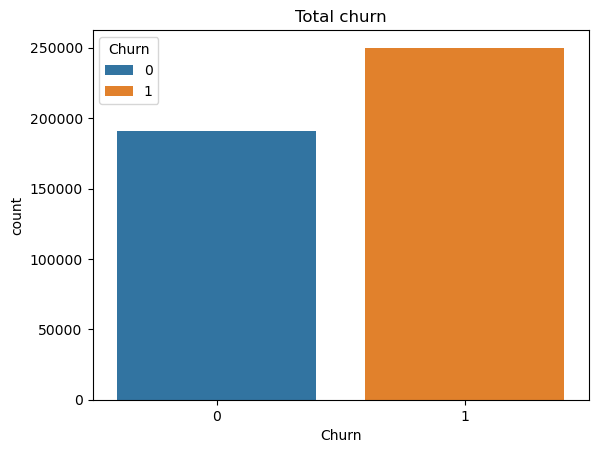

In [21]:
#Calculate the total Churn

sns.countplot(x ='Churn', hue = 'Churn', data = customer)
plt.title('Total churn')
plt.legend(title = 'Churn')
plt.show()  

#There are more client that have left the service provides

In [22]:
#Total spend by subscription type

contract_type = customer.groupby('Subscription Type')['Total Spend'].mean().reset_index()
contract_type.round(2)

#There is not much differences in total spend based on the subscription type

,Subscription Type,Total Spend
0,Basic,628.67
1,Premium,632.93
2,Standard,633.13


In [23]:
#Total spend by the gender & subscription type 

customer_age_subscript = customer.groupby(['Gender', 'Subscription Type'])['Total Spend'].mean().reset_index()
customer_age_subscript.round(2)


#Male spend more money avaraging 645.47 bucks while female total spend average 613.33 bucks which is 32.14 bucks less

,Gender,Subscription Type,Total Spend
0,Female,Basic,610.87
1,Female,Premium,613.41
2,Female,Standard,615.72
3,Male,Basic,642.26
4,Male,Premium,647.66
5,Male,Standard,646.49


   index  Churn   count
0      0      0  190833
1      1      1  249999


<ipython-input-24-dc006aba2d5b>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = 'Churn')


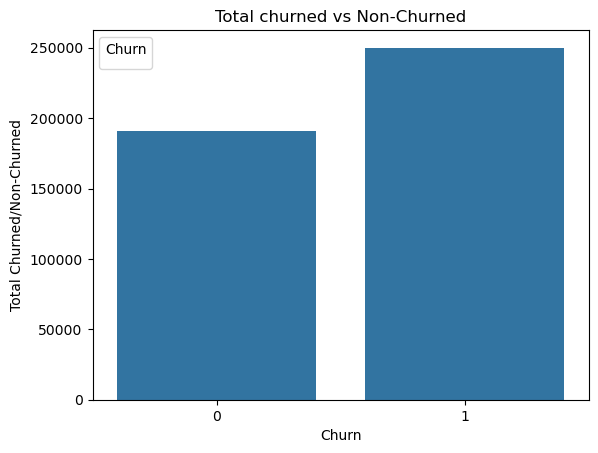

In [24]:
#Calculate the total Churn
Churned_count = customer.groupby('Churn')['Churn'].value_counts().reset_index()
Churned_count

#Print the total number of clients that churned and thise that remained
print(Churned_count.reset_index())

sns.countplot(x ='Churn', data = customer)
plt.title('Total churned vs Non-Churned')
plt.legend(title = 'Churn')
plt.ylabel('Total Churned/Non-Churned')
plt.show()  

#249999

Text(0.5, 1.0, 'Count for different subscriptions')

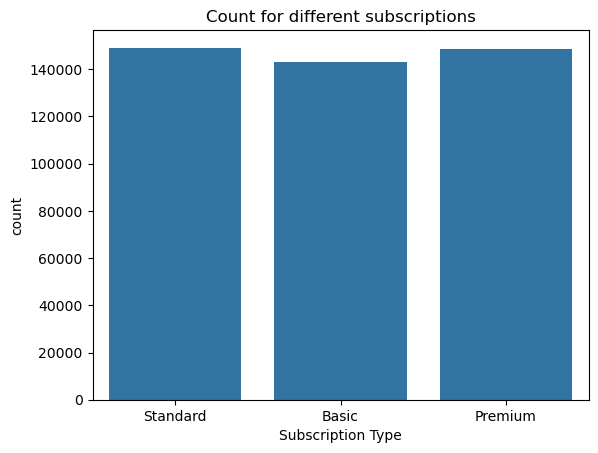

In [52]:
# What the most prefered subscription type

sns.countplot(x= 'Subscription Type', data = customer)
plt.title ('Count for different subscriptions')

#There is insignificant difference between prefered subscription types acrosss the dataset.
#Indicating a uniform data distributions 


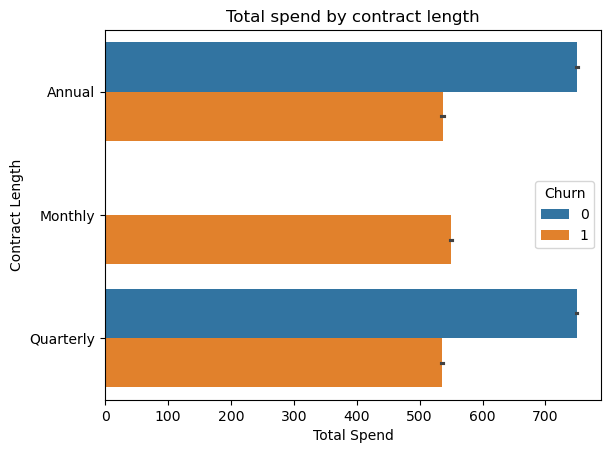

In [26]:


sns.barplot(y = 'Contract Length', x ='Total Spend', hue = 'Churn', data = customer)
plt.title ('Total spend by contract length')
plt.show()
##Annual and Quartely subscribe spend around the same amount of 600 bucks, While monthly subscriber are spending less by 50 bucks. There is also a clear distinct that t

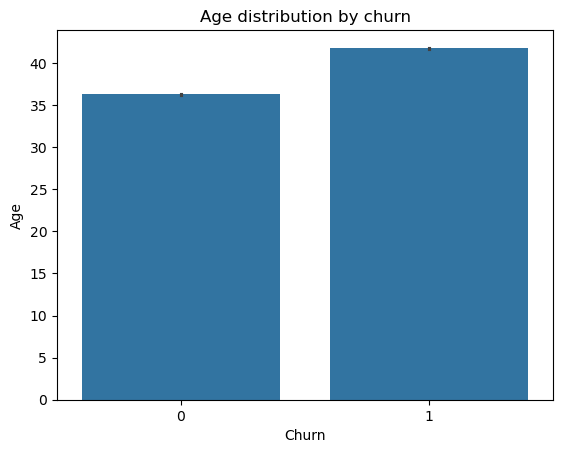

In [27]:
sns.barplot( x= 'Churn', y='Age', data = customer)
plt.title ('Age distribution by churn')
plt.show()

In [28]:
customer.sample(3)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
582,591,25,Female,33,25,6,12,Basic,Annual,571.00,2,1
405261,412376,35,Female,3,1,3,19,Standard,Annual,580.35,7,0
197983,202794,61,Male,35,21,0,22,Basic,Monthly,120.00,3,1


<Axes: >

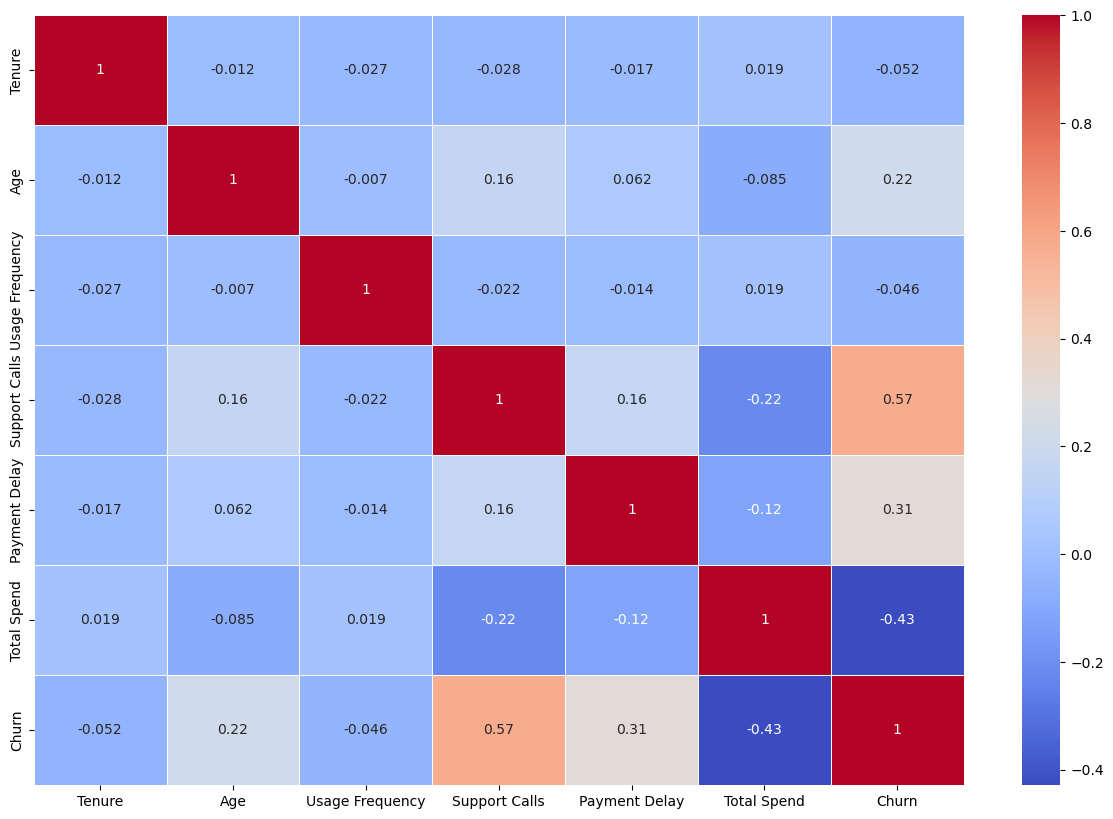

In [29]:
#Evalaute correlations between independent variable against churn
correlation = customer[['Tenure', 'Age', 'Usage Frequency','Support Calls', 'Payment Delay', 'Total Spend', 'Churn']].corr().round(3)
plt.figure(figsize = (15,10))
sns.heatmap(correlation, cmap = 'coolwarm', annot =True, linewidth =0.5)

In [30]:
#List all the variables base on their correlation relative to Churn

correlation_orders = abs(correlation['Churn'].drop('Churn').sort_values(ascending = True))
correlation_orders.round(3)

Total Spend        0.429
Tenure             0.052
Usage Frequency    0.046
Age                0.218
Payment Delay      0.312
Support Calls      0.574
Name: Churn, dtype: float64

***There is a strong correlation between the Churn and Support Calls, Contract Length_Monthly  and Payment Delay. And there is a weak correlation between with Subscription Type_Standard and Subscription Type_Preminium***

In [ ]:
**

**MODELLING DATA DEFINITION**

In [31]:
#Define the variables to be tested
X = customer.drop(columns = {'Churn', 'CustomerID'})
y = customer['Churn']

In [32]:
#Split the test data into train and testing

X_train, X_test,y_train, y_test = train_test_split (X, y,  test_size = 0.25, random_state = 42, stratify = y)

#Print the shape of X-train

X_train.shape

(330624, 10)

In [33]:
#Standardize contrinuous and numerical variables 

numeric_columns = X_train.select_dtypes(include = ['float64', 'int64']).columns

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(X_train[numeric_columns])
X_test_numeric = scaler.transform(X_test[numeric_columns])


In [34]:
#Use OneHotEncoder to change catehorical variables

categorical_columns = X.select_dtypes(include = 'object').columns
encoder = OneHotEncoder(sparse_output = False, drop = "first")
X_train_encoded = encoder.fit_transform(X_train[categorical_columns])
X_test_encoded = encoder.transform(X_test[categorical_columns])


<ipython-input-34-1aa4b3a957c5>:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include = 'object').columns


In [35]:
#Combine the X_train and test for categprical and numerical data

X_train = np.hstack([X_train_numeric, X_train_encoded])
X_test = np.hstack([X_test_numeric, X_test_encoded])

**LOGISTIC REGRESSION MODEL**

In [36]:
#Define the model

log_reg =  LogisticRegression()

#Fit the model

model = log_reg.fit(X_train,  y_train)

#Print the Intercepet and coef

print (f'coef: {model.coef_}')
print(f'intercept: {model.intercept_}')

coef: [[-1.15674926e+00 -7.69622045e-01 -8.53219287e-02 -8.33240552e-02
   9.17961760e+00 -8.60241776e-03]]
intercept: [0.45156478]


In [37]:
#Use the test data to make predictions
y_pred = model.predict(X_test)

#Evalaute the model performances

print (f'Accuracy score:  {np.round(100*accuracy_score(y_pred,y_test),2)} %')


Accuracy score:  76.9 %


In [38]:
logreg_classification = pd.DataFrame(classification_report(y_test,y_pred, output_dict = True)).transpose().round(3)
logreg_classification

,precision,recall,f1-score,support
0,0.710,0.788,0.747,47708.000
1,0.824,0.754,0.787,62500.000
accuracy,0.769,0.769,0.769,0.769
macro avg,0.767,0.771,0.767,110208.000
weighted avg,0.774,0.769,0.770,110208.000


**DECISION TREE MODEL**

In [39]:
#Decision Tree Model
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Define the model
tree_model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 5)

#Fit gtraining data into the model

tree_model.fit(X_train, y_train)

#Make prediction using the testing data

y_tree_pred = tree_model.predict(X_test)

#Evaluate the model performance 

print(f"Decision Tree Model accuracy score: {np.round(accuracy_score(y_tree_pred, y_test)*100,3)}%")


Decision Tree Model accuracy score: 80.714%


In [40]:
pd.DataFrame(classification_report(y_test,y_tree_pred, output_dict= True)).round(3)


,0,1,accuracy,macro avg,weighted avg
precision,0.692,1.000,0.807,0.846,0.866
recall,1.000,0.660,0.807,0.830,0.807
f1-score,0.818,0.795,0.807,0.806,0.805
support,47708.000,62500.000,0.807,110208.000,110208.000


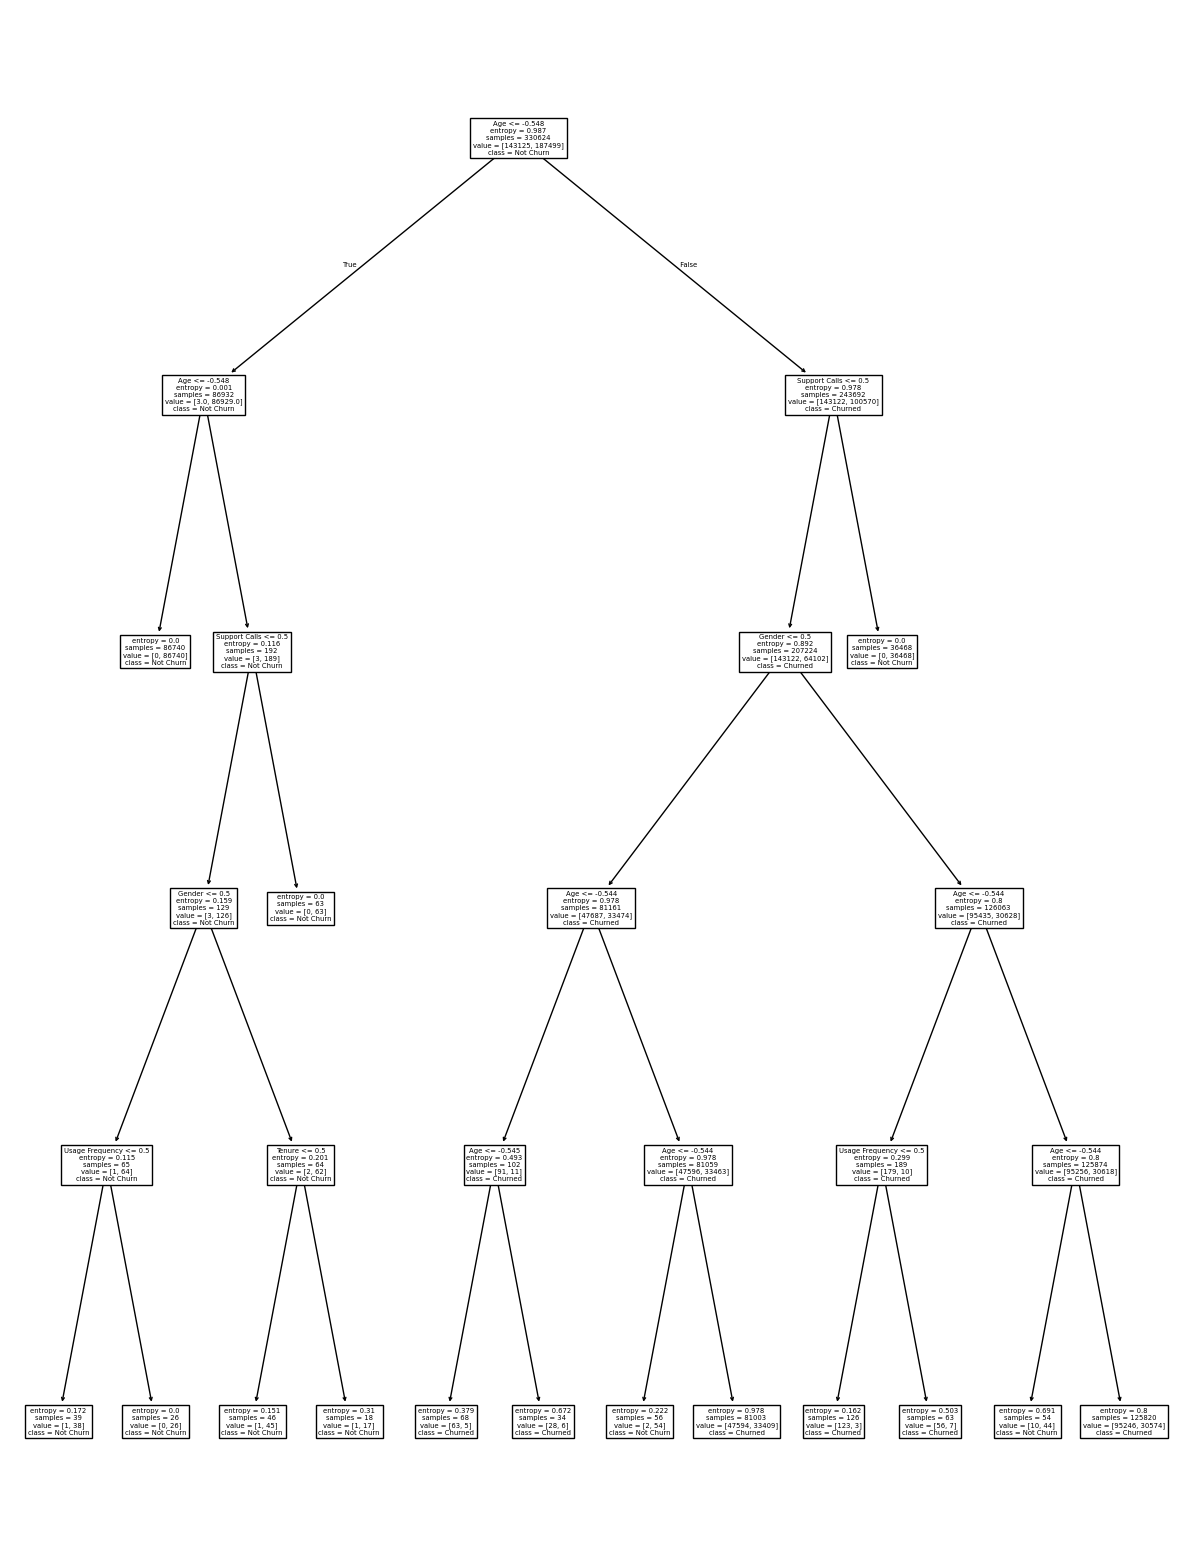

In [41]:
#Plot the tree branches of the model

plt.figure(figsize = (15,20))
plot_tree(tree_model,
          feature_names = X.columns,
         class_names = ['Churned', 'Not Churn'])
plt.show()

**RANDOM FOREST AND XGBOOST MODEL**

In [42]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
n_estimators = 200
#Define my Random Forest and XGB Models

rf = RandomForestClassifier(n_estimators = n_estimators, random_state =42)

xgb =  XGBClassifier(n_estimators = n_estimators, random_state =42)

#Fit both model

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

#Make prediction

y_rf_pred = rf.predict(X_test)

y_xgb_pred = xgb.predict(X_test)


print(f'rf accuracy_score{accuracy_score(y_rf_pred, y_test)}')
print(f'xgb accuracy_score{accuracy_score(y_xgb_pred, y_test)}')


rf accuracy_score0.9054878048780488
xgb accuracy_score0.8046602787456446


In [44]:
#Print classification report for random forest and XGBoost
print("Random Forest Classification Report")
pd.DataFrame(classification_report(y_test, y_rf_pred, output_dict = True)).transpose().round(3)


Random Forest Classification Report


,precision,recall,f1-score,support
0,0.913,0.864,0.888,47708.000
1,0.900,0.937,0.918,62500.000
accuracy,0.905,0.905,0.905,0.905
macro avg,0.907,0.901,0.903,110208.000
weighted avg,0.906,0.905,0.905,110208.000


In [45]:

print("RGBoost Classification Report")
pd.DataFrame(classification_report(y_test, y_xgb_pred, output_dict = True)).transpose().round(3)

RGBoost Classification Report


,precision,recall,f1-score,support
0,0.695,0.980,0.813,47708.000
1,0.977,0.671,0.796,62500.000
accuracy,0.805,0.805,0.805,0.805
macro avg,0.836,0.825,0.804,110208.000
weighted avg,0.855,0.805,0.803,110208.000


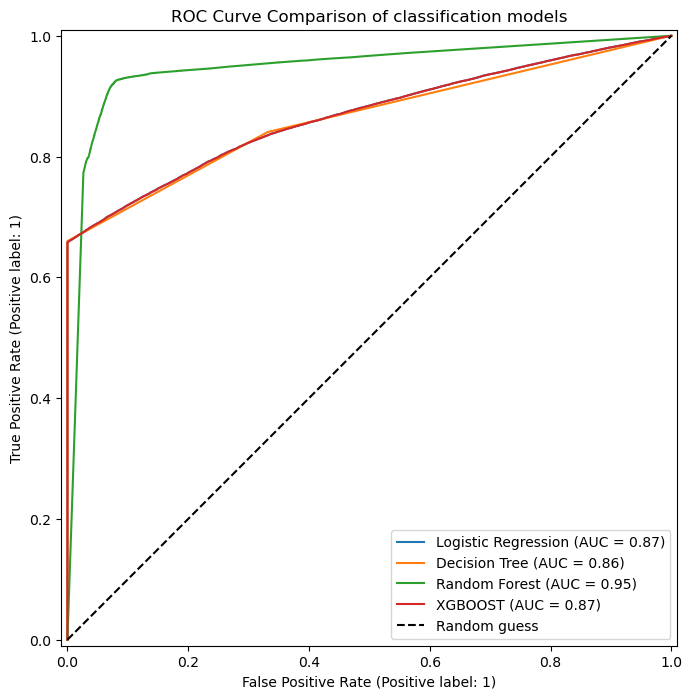

In [50]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize = (10,8))
models = {'Logistic Regression': model,
          'Decision Tree':tree_model,
          'Random Forest': rf,
          'XGBOOST': xgb}

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0,1], [0,1], "k--", label ='Random guess')
ax.legend()
plt.title("ROC Curve Comparison of classification models")
plt.show()

#The model selected for this data is Random Forest Classifier

**Classification Report**

Four classification models were trained to predict customer churn: Logistic Regression, Decision Tree, Random Forest and XGBoost. The data was split 75% training and 25% testing. Numeric features were standardized with a StandardScaler fitted on the training set only, and categorical variables were one-hot encoded. The target variable Churn was not transformed.
Logistic Regression, the baseline model, reached 76.9% accuracy. For churners, precision was 82.4%, recall 75.4% and F1 78.7%. The Decision Tree reached 80.7% accuracy. For churners, precision was 100% but recall only 66%, so it caught about 41,250 of the 62,500 actual churners (F1 79.5%). For non-churners, precision was 69.2% and recall 100%. XGBoost reached 80.5% accuracy. For churners, precision was 97.7% and recall 67.1%.

Random Forest performed best overall, with the highest ROC AUC (0.95, against 0.87 for Logistic Regression and XGBoost and 0.86 for the Decision Tree). It reached 90.5% accuracy. For churners, precision was 90.0%, recall 93.7% and F1 91.8%. For non-churners, precision was 91.3% and recall 86.4%

Random Forest is the recommended model, with the highest accuracy (90.5%), the best balance of precision and recall on churners, and the highest AUC (0.95). The Decision Tree and XGBoost reached very high churn precision (100% and 97.7%) but missed about a third of churners, which is costly if the goal is to catch customers before they leave